In [2]:
# Install required libraries (run in terminal or notebook cell)
%pip install pandas numpy scikit-learn xgboost matplotlib seaborn

/home/muhammad-awais-qarni/Downloads/Sales forecast/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [51]:
# Load dataset
df = pd.read_csv('Supplement_Sales_Weekly_Expanded.csv')

# Basic exploration
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("\nData Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (4384, 13)

Column Names:
['Date', 'Product Name', 'Category', 'Inventory Level', 'Units Sold', 'Unit Order', 'Actual Price', 'Unit Price', 'Discount', 'Total Price', 'Revenue', 'Region', 'Holiday/Promotion']

First 5 rows:
         Date  Product Name     Category  Inventory Level  Units Sold  \
0  01/06/2020  Whey Protein      Protein              260         143   
1  01/06/2020     Vitamin C      Vitamin              141         139   
2  01/06/2020      Fish Oil        Omega              426         161   
3  01/06/2020  Multivitamin      Vitamin              124         140   
4  01/06/2020   Pre-Workout  Performance              181         157   

   Unit Order  Actual Price  Unit Price  Discount  Total Price   Revenue  \
0         215         23.99       31.98      0.03      4573.14  1,143.29   
1         209         31.88       42.51      0.04      5908.89  1,477.22   
2         242          9.68       12.91      0.25      2078.51    519.63   
3         210     

In [53]:
# ✅ FIX: Convert Date with correct format (MM/DD/YYYY)
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')  # American date format

# Sort by date
df = df.sort_values('Date').reset_index(drop=True)

# ✅ CRITICAL: Convert ALL numeric columns properly
numeric_columns = ['Inventory Level', 'Units Sold', 'Unit Order', 
                   'Actual Price', 'Unit Price', 'Discount', 
                   'Total Price', 'Revenue', 'Holiday/Promotion']

for col in numeric_columns:
    # Remove any commas or spaces that might be in numbers
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.replace(',', '').str.replace(' ', '').str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Check for NaN values
print("\n❗ Missing values after conversion:")
print(df[numeric_columns].isnull().sum())

# Show problematic rows if any
nan_rows = df[df[numeric_columns].isnull().any(axis=1)]
if len(nan_rows) > 0:
    print(f"\n⚠️ Found {len(nan_rows)} rows with NaN values:")
    print(nan_rows[['Date', 'Product Name', 'Category'] + numeric_columns].head())
    print("\nDropping these rows...")

# Handle missing values
df = df.dropna()  # Drop rows with NaN
df = df.reset_index(drop=True)

print(f"\n✅ Dataset shape after cleaning: {df.shape}")

# Encode categorical variables
le_product = LabelEncoder()
le_category = LabelEncoder()
le_region = LabelEncoder()

df['Product_Encoded'] = le_product.fit_transform(df['Product Name'])
df['Category_Encoded'] = le_category.fit_transform(df['Category'])
df['Region_Encoded'] = le_region.fit_transform(df['Region'])

# Extract time features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week
df['Quarter'] = df['Date'].dt.quarter
df['DayOfYear'] = df['Date'].dt.dayofyear

print("\n✅ Preprocessing completed!")
print("\nFirst few rows after preprocessing:")
print(df[['Date', 'Product Name', 'Category', 'Units Sold', 'Product_Encoded', 'Region_Encoded']].head())
print("\nData types:")
print(df[numeric_columns].dtypes)


❗ Missing values after conversion:
Inventory Level      0
Units Sold           0
Unit Order           0
Actual Price         0
Unit Price           0
Discount             0
Total Price          0
Revenue              0
Holiday/Promotion    0
dtype: int64

✅ Dataset shape after cleaning: (4384, 13)

✅ Preprocessing completed!

First few rows after preprocessing:
        Date        Product Name    Category  Units Sold  Product_Encoded  \
0 2020-01-06        Whey Protein     Protein         143               14   
1 2020-01-06  Electrolyte Powder   Hydration         154                5   
2 2020-01-06     Iron Supplement     Mineral         149                8   
3 2020-01-06   Green Tea Extract  Fat Burner         143                7   
4 2020-01-06              Biotin     Vitamin         159                2   

   Region_Encoded  
0               3  
1               3  
2               0  
3               0  
4               1  

Data types:
Inventory Level        int64
Units Sold

In [54]:
def create_lag_features(df, target_col='Units Sold', lags=[1, 2, 3, 4]):
    """Create lag features grouped by Product and Category"""
    df_lag = df.copy()
    
    # Sort by Product, Category, and Date
    df_lag = df_lag.sort_values(['Product Name', 'Category', 'Date']).reset_index(drop=True)
    
    for lag in lags:
        df_lag[f'Units_Sold_Lag_{lag}'] = df_lag.groupby(['Product Name', 'Category'])[target_col].shift(lag)
    
    # Rolling features (4-week window)
    df_lag['Units_Sold_Rolling_Mean_4'] = df_lag.groupby(['Product Name', 'Category'])[target_col].transform(
        lambda x: x.rolling(window=4, min_periods=1).mean()
    )
    df_lag['Units_Sold_Rolling_Std_4'] = df_lag.groupby(['Product Name', 'Category'])[target_col].transform(
        lambda x: x.rolling(window=4, min_periods=1).std()
    )
    
    # Fill NaN in std with 0
    df_lag['Units_Sold_Rolling_Std_4'] = df_lag['Units_Sold_Rolling_Std_4'].fillna(0)
    
    return df_lag

# Create lag features
df = create_lag_features(df)

# Drop rows with NaN (first few rows per product due to lag)
print(f"Shape before dropping NaN: {df.shape}")
df = df.dropna().reset_index(drop=True)
print(f"Shape after dropping NaN: {df.shape}")

print("\n✅ Feature engineering completed!")
print(f"Total features: {len(df.columns)}")

Shape before dropping NaN: (4384, 27)
Shape after dropping NaN: (4320, 27)

✅ Feature engineering completed!
Total features: 27


In [55]:
# Define features and target
feature_cols = [
    'Product_Encoded', 'Category_Encoded', 'Region_Encoded',
    'Inventory Level', 'Unit Order', 'Actual Price', 'Unit Price', 
    'Discount', 'Total Price', 'Revenue', 'Holiday/Promotion',
    'Year', 'Month', 'Week', 'Quarter', 'DayOfYear',
    'Units_Sold_Lag_1', 'Units_Sold_Lag_2', 'Units_Sold_Lag_3', 'Units_Sold_Lag_4',
    'Units_Sold_Rolling_Mean_4', 'Units_Sold_Rolling_Std_4'
]

target_col = 'Units Sold'

X = df[feature_cols]
y = df[target_col]

# Check data types
print("Feature data types:")
print(X.dtypes)
print("\nAny non-numeric features?")
print(X.select_dtypes(include=['object']).columns.tolist())

# Split data (80-20, time-ordered)
split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"\n✅ Training set: {X_train.shape}")
print(f"✅ Testing set: {X_test.shape}")
print(f"\nTarget distribution:")
print(f"  Train mean: {y_train.mean():.2f}, std: {y_train.std():.2f}")
print(f"  Test mean: {y_test.mean():.2f}, std: {y_test.std():.2f}")

Feature data types:
Product_Encoded                int64
Category_Encoded               int64
Region_Encoded                 int64
Inventory Level                int64
Unit Order                     int64
Actual Price                 float64
Unit Price                   float64
Discount                     float64
Total Price                  float64
Revenue                      float64
Holiday/Promotion              int64
Year                           int32
Month                          int32
Week                          UInt32
Quarter                        int32
DayOfYear                      int32
Units_Sold_Lag_1             float64
Units_Sold_Lag_2             float64
Units_Sold_Lag_3             float64
Units_Sold_Lag_4             float64
Units_Sold_Rolling_Mean_4    float64
Units_Sold_Rolling_Std_4     float64
dtype: object

Any non-numeric features?
[]

✅ Training set: (3456, 22)
✅ Testing set: (864, 22)

Target distribution:
  Train mean: 150.25, std: 12.43
  Test mean: 1

In [56]:
# Initialize XGBoost Regressor
model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1  # Use all CPU cores
)

# Train the model
print("🚀 Training XGBoost model...")
model.fit(X_train, y_train)
print("✅ Training completed!")

🚀 Training XGBoost model...
✅ Training completed!


In [57]:
# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Calculate metrics
train_mae = mean_absolute_error(y_train, y_pred_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
train_r2 = r2_score(y_train, y_pred_train)

test_mae = mean_absolute_error(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_r2 = r2_score(y_test, y_pred_test)

print("="*50)
print("MODEL PERFORMANCE")
print("="*50)
print(f"\nTraining Set:")
print(f"  MAE:  {train_mae:.2f}")
print(f"  RMSE: {train_rmse:.2f}")
print(f"  R²:   {train_r2:.4f}")

print(f"\nTest Set:")
print(f"  MAE:  {test_mae:.2f}")
print(f"  RMSE: {test_rmse:.2f}")
print(f"  R²:   {test_r2:.4f}")

# Check for overfitting
print(f"\n📊 Overfitting check:")
print(f"  R² difference: {abs(train_r2 - test_r2):.4f}")
if abs(train_r2 - test_r2) < 0.05:
    print("  ✅ No overfitting detected!")
else:
    print("  ⚠️ Possible overfitting")

MODEL PERFORMANCE

Training Set:
  MAE:  0.26
  RMSE: 0.33
  R²:   0.9993

Test Set:
  MAE:  0.39
  RMSE: 0.52
  R²:   0.9982

📊 Overfitting check:
  R² difference: 0.0011
  ✅ No overfitting detected!


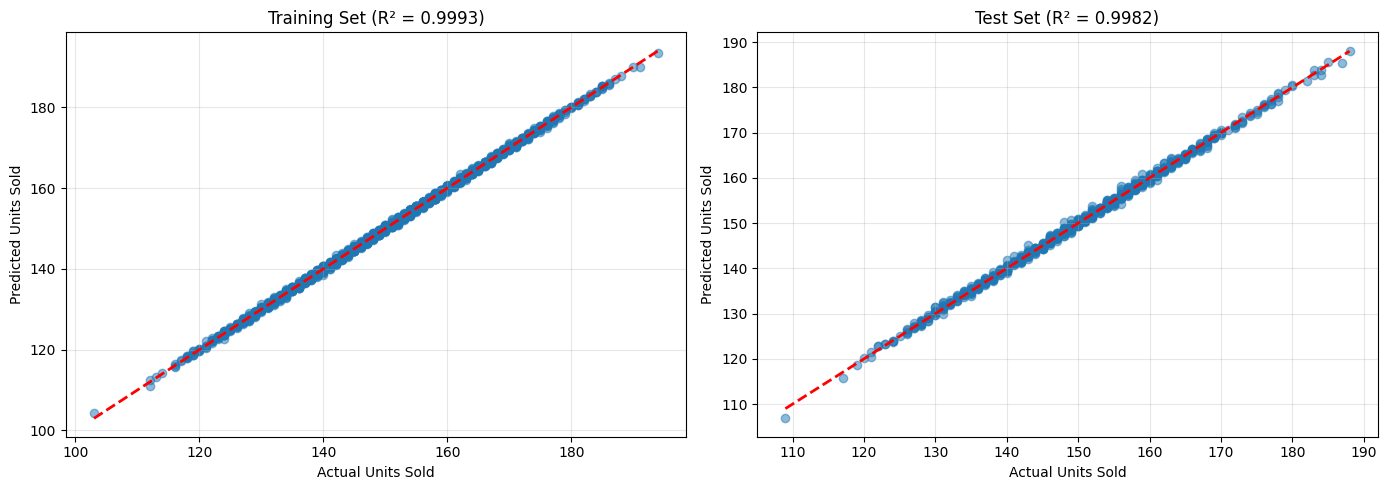

✅ Saved: graphs/actual_vs_predicted.png


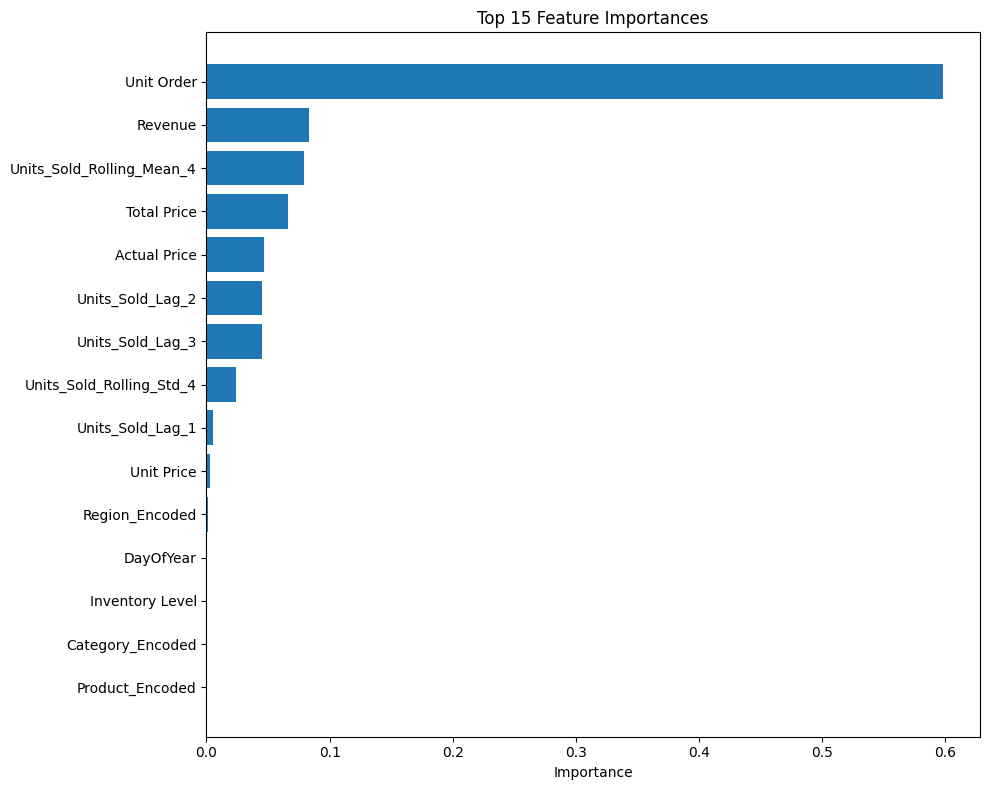

✅ Saved: graphs/feature_importance.png


In [58]:
# Create graphs folder
os.makedirs('graphs', exist_ok=True)

# Plot 1: Actual vs Predicted
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_train, y_pred_train, alpha=0.5)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('Actual Units Sold')
plt.ylabel('Predicted Units Sold')
plt.title(f'Training Set (R² = {train_r2:.4f})')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Units Sold')
plt.ylabel('Predicted Units Sold')
plt.title(f'Test Set (R² = {test_r2:.4f})')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('graphs/actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: graphs/actual_vs_predicted.png")

# Plot 2: Feature Importance
plt.figure(figsize=(10, 8))
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.barh(feature_importance['Feature'][:15], feature_importance['Importance'][:15])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('graphs/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: graphs/feature_importance.png")

In [59]:
# Create models folder
os.makedirs('models', exist_ok=True)

# Save model in both formats
model.save_model('models/xgboost_stock_predictor.json')
with open('models/xgboost_stock_predictor.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save encoders
with open('models/label_encoders.pkl', 'wb') as f:
    pickle.dump({
        'product': le_product,
        'category': le_category,
        'region': le_region
    }, f)

# Save feature columns
with open('models/feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

# Save the processed dataframe (for prediction function)
df.to_csv('models/processed_data.csv', index=False)

print("\n✅ Models saved in 'models' folder:")
print("   - xgboost_stock_predictor.json")
print("   - xgboost_stock_predictor.pkl")
print("   - label_encoders.pkl")
print("   - feature_columns.pkl")
print("   - processed_data.csv")


✅ Models saved in 'models' folder:
   - xgboost_stock_predictor.json
   - xgboost_stock_predictor.pkl
   - label_encoders.pkl
   - feature_columns.pkl
   - processed_data.csv


In [63]:
def predict_future_stock(product_name, category, duration_weeks):
    """
    Predict future stock (case-insensitive)
    
    Parameters:
    - product_name: str (case-insensitive)
    - category: str (case-insensitive)
    - duration_weeks: int
    
    Returns:
    - predictions: list of weekly predictions
    - total_stock: sum of predictions
    """
    # Case-insensitive matching
    product_name = product_name.strip().title()
    category = category.strip().title()
    
    # Get latest 4 weeks data for this product
    product_data = df[(df['Product Name'].str.title() == product_name) & 
                      (df['Category'].str.title() == category)].tail(4)
    
    if len(product_data) == 0:
        print(f"❌ Error: Product '{product_name}' with category '{category}' not found!")
        print("\n📋 Available Products:")
        for prod in sorted(df['Product Name'].unique()):
            cat = df[df['Product Name'] == prod]['Category'].iloc[0]
            print(f"   - {prod} ({cat})")
        return None, None
    
    # Get actual names from data
    actual_product = product_data.iloc[0]['Product Name']
    actual_category = product_data.iloc[0]['Category']
    actual_region = product_data.iloc[0]['Region']
    
    # Get encoded values
    product_encoded = le_product.transform([actual_product])[0]
    category_encoded = le_category.transform([actual_category])[0]
    region_encoded = le_region.transform([actual_region])[0]
    
    # Get latest row values
    latest_row = product_data.iloc[-1]
    
    predictions = []
    
    for week in range(duration_weeks):
        # Prepare features
        features = {
            'Product_Encoded': product_encoded,
            'Category_Encoded': category_encoded,
            'Region_Encoded': region_encoded,
            'Inventory Level': latest_row['Inventory Level'],
            'Unit Order': latest_row['Unit Order'],
            'Actual Price': latest_row['Actual Price'],
            'Unit Price': latest_row['Unit Price'],
            'Discount': latest_row['Discount'],
            'Total Price': latest_row['Total Price'],
            'Revenue': latest_row['Revenue'],
            'Holiday/Promotion': 0,
            'Year': latest_row['Year'],
            'Month': latest_row['Month'],
            'Week': (latest_row['Week'] + week + 1) % 53,  # Handle week overflow
            'Quarter': latest_row['Quarter'],
            'DayOfYear': latest_row['DayOfYear'],
            'Units_Sold_Lag_1': product_data.iloc[-1]['Units Sold'],
            'Units_Sold_Lag_2': product_data.iloc[-2]['Units Sold'] if len(product_data) > 1 else product_data.iloc[-1]['Units Sold'],
            'Units_Sold_Lag_3': product_data.iloc[-3]['Units Sold'] if len(product_data) > 2 else product_data.iloc[-1]['Units Sold'],
            'Units_Sold_Lag_4': product_data.iloc[-4]['Units Sold'] if len(product_data) > 3 else product_data.iloc[-1]['Units Sold'],
            'Units_Sold_Rolling_Mean_4': product_data['Units Sold'].mean(),
            'Units_Sold_Rolling_Std_4': product_data['Units Sold'].std() if len(product_data) > 1 else 0
        }
        
        # Create DataFrame with correct column order
        X_pred = pd.DataFrame([features])[feature_cols]
        
        # Predict
        pred = model.predict(X_pred)[0]
        predictions.append(int(max(0, pred)))  # Ensure non-negative
        
        # Update for next iteration
        product_data = pd.concat([product_data, pd.DataFrame([{'Units Sold': pred}])]).tail(4)
    
    total_stock = sum(predictions)
    
    return predictions, total_stock


# Test predictions
print("\n" + "="*60)
print("PREDICTION TESTS")
print("="*60)

# Test 1
predictions, total = predict_future_stock("Vitamin C", "Vitamin", 4)
if predictions:
    print(f"\n✅ Product: Vitamin C | Category: Vitamin | Duration: 4 weeks")
    print(f"   Weekly: {predictions}")
    print(f"   Total: {total} units")

# Test 2
predictions, total = predict_future_stock("whey protein", "protein", 8)
if predictions:
    print(f"\n✅ Product: Whey Protein | Category: Protein | Duration: 8 weeks")
    print(f"   Weekly: {predictions}")
    print(f"   Total: {total} units")

# Test 3
predictions, total = predict_future_stock("zinc", "mineral", 4)
if predictions:
    print(f"\n✅ Product: Zinc | Category: Mineral | Duration: 4 weeks")
    print(f"   Weekly: {predictions}")
    print(f"   Total: {total} units")


PREDICTION TESTS

✅ Product: Vitamin C | Category: Vitamin | Duration: 4 weeks
   Weekly: [156, 154, 155, 156]
   Total: 621 units

✅ Product: Whey Protein | Category: Protein | Duration: 8 weeks
   Weekly: [147, 148, 148, 147, 147, 147, 148, 147]
   Total: 1179 units

✅ Product: Zinc | Category: Mineral | Duration: 4 weeks
   Weekly: [147, 146, 147, 147]
   Total: 587 units


In [64]:
import pandas as pd
import numpy as np
import pickle
import xgboost as xgb

# ============================================
# STEP 1: Load Saved Model & Encoders
# ============================================
# Load model (choose one format)
with open('models/xgboost_stock_predictor.pkl', 'rb') as f:
    model = pickle.load(f)

# Load encoders
with open('models/label_encoders.pkl', 'rb') as f:
    encoders = pickle.load(f)
    le_product = encoders['product']
    le_category = encoders['category']
    le_region = encoders['region']

# Load your original data (needed for lag features)
df = pd.read_csv('Supplement_Sales_Weekly_Expanded.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Convert numeric columns
numeric_columns = ['Inventory Level', 'Units Sold', 'Unit Order', 
                   'Actual Price', 'Unit Price', 'Discount', 
                   'Total Price', 'Revenue']
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.fillna(0)

print("✅ Model and data loaded successfully!")

✅ Model and data loaded successfully!


In [68]:
import pandas as pd
import pickle
import xgboost as xgb

# ============================================
# Load Model & Data
# ============================================
# Load model
with open('models/xgboost_stock_predictor.pkl', 'rb') as f:
    trained_model = pickle.load(f)

# Load encoders
with open('models/label_encoders.pkl', 'rb') as f:
    encoders = pickle.load(f)
    le_product = encoders['product']
    le_category = encoders['category']
    le_region = encoders['region']

# Load feature columns
with open('models/feature_columns.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

# Load processed data
df = pd.read_csv('models/processed_data.csv')
df['Date'] = pd.to_datetime(df['Date'])

print("✅ Model loaded successfully!")

✅ Model loaded successfully!


In [70]:

# Prediction Function
# ============================================
def predict_stock(product_name, category, weeks):
    """Predict future stock"""
    product_name = product_name.strip().title()
    category = category.strip().title()
    
    product_data = df[(df['Product Name'].str.title() == product_name) & 
                      (df['Category'].str.title() == category)].tail(4)
    
    if len(product_data) == 0:
        print(f"❌ Product '{product_name}' not found!")
        return None, None
    
    actual_product = product_data.iloc[0]['Product Name']
    actual_category = product_data.iloc[0]['Category']
    actual_region = product_data.iloc[0]['Region']
    
    product_encoded = le_product.transform([actual_product])[0]
    category_encoded = le_category.transform([actual_category])[0]
    region_encoded = le_region.transform([actual_region])[0]
    
    latest_row = product_data.iloc[-1]
    predictions = []
    
    for week in range(weeks):
        features = {
            'Product_Encoded': product_encoded,
            'Category_Encoded': category_encoded,
            'Region_Encoded': region_encoded,
            'Inventory Level': latest_row['Inventory Level'],
            'Unit Order': latest_row['Unit Order'],
            'Actual Price': latest_row['Actual Price'],
            'Unit Price': latest_row['Unit Price'],
            'Discount': latest_row['Discount'],
            'Total Price': latest_row['Total Price'],
            'Revenue': latest_row['Revenue'],
            'Holiday/Promotion': 0,
            'Year': latest_row['Year'],
            'Month': latest_row['Month'],
            'Week': (latest_row['Week'] + week + 1) % 53,
            'Quarter': latest_row['Quarter'],
            'DayOfYear': latest_row['DayOfYear'],
            'Units_Sold_Lag_1': product_data.iloc[-1]['Units Sold'],
            'Units_Sold_Lag_2': product_data.iloc[-2]['Units Sold'] if len(product_data) > 1 else product_data.iloc[-1]['Units Sold'],
            'Units_Sold_Lag_3': product_data.iloc[-3]['Units Sold'] if len(product_data) > 2 else product_data.iloc[-1]['Units Sold'],
            'Units_Sold_Lag_4': product_data.iloc[-4]['Units Sold'] if len(product_data) > 3 else product_data.iloc[-1]['Units Sold'],
            'Units_Sold_Rolling_Mean_4': product_data['Units Sold'].mean(),
            'Units_Sold_Rolling_Std_4': product_data['Units Sold'].std() if len(product_data) > 1 else 0
        }
        
        X_pred = pd.DataFrame([features])[feature_cols]
        pred = trained_model.predict(X_pred)[0]
        predictions.append(int(max(0, pred)))
        product_data = pd.concat([product_data, pd.DataFrame([{'Units Sold': pred}])]).tail(4)
    
    return predictions, sum(predictions)

# ============================================
# Test Predictions
# ============================================
predictions, total = predict_stock("Zinc", "mineral", 4)
if predictions:
    print(f"\n✅Zinc  Weekly: {predictions}")
    print(f"✅ Total: {total} units")

predictions, total = predict_stock("whey protein", "protein", 8)
if predictions:
    print(f"\n✅whey protien Weekly: {predictions}")
    print(f"✅ Total: {total} units")


✅Zinc  Weekly: [147, 146, 147, 147]
✅ Total: 587 units

✅whey protien Weekly: [147, 148, 148, 147, 147, 147, 148, 147]
✅ Total: 1179 units
